# Batch Independent GPQR

In [ ]:
import os

import torch
from torch.distributions import Normal
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.means import ConstantMean
from gpytorch.kernels import RBFKernel, ScaleKernel
from gpytorch.mlls import VariationalELBO
import matplotlib.pyplot as plt

from gpytorch_qr.models import DirectQuantileGP
from gpytorch_qr.gpqr import BatchQuantileGPLikelihood

try:
    import sys

    sys.path.insert(0, os.path.abspath(".."))

    import config_notebook
except ImportError:
    print("Output will not be deterministic SVG.")

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

n_epochs = int(os.getenv("GPYTORCHQR_N_EPOCHS", 5000))

## Data preparation

In [ ]:
def mean(x):
    return torch.cos(x[..., 0] * 2 * 3.14) * torch.cos(x[..., 1] * 2 * 3.14)


def std(x):
    return x[..., 0] + x[..., 1] + 0.1


x2_values = torch.tensor([0.1, 0.5, 0.9]).to(device)
n_per_x2 = 500
x = torch.stack(
    [
        torch.rand(n_per_x2 * len(x2_values)).to(device),
        x2_values.repeat_interleave(n_per_x2),
    ],
    dim=1,
)

y = (mean(x) + torch.randn(x.shape[0], device=device).mul(std(x))).squeeze()

q = torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9]).to(device)

In [ ]:
x1_pred = torch.linspace(0, 1, 100).to(device)
x_pred = torch.stack(
    [
        x1_pred.unsqueeze(0).expand(len(x2_values), -1),
        x2_values.unsqueeze(1).expand(-1, len(x1_pred)),
    ],
    dim=-1,
)

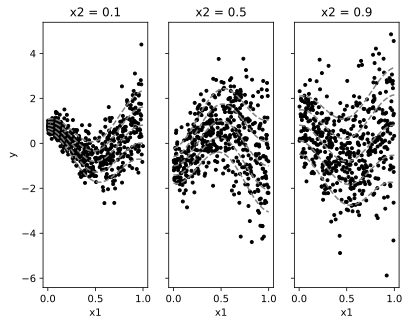

In [ ]:
fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    mask = x[:, 1] == x2_val
    ax.scatter(x[mask, 0].cpu(), y[mask].cpu(), c="k", marker=".")

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)
    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="gray")

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()

## Define model and likelihood

In [ ]:
class MyGP(DirectQuantileGP):
    def __init__(self, inducing_points, num_quantiles):
        N, D = inducing_points.size()
        variational_distribution = CholeskyVariationalDistribution(
            N,
            batch_shape=torch.Size([num_quantiles]),
        )
        variational_strategy = VariationalStrategy(
            self,
            inducing_points,
            variational_distribution,
            learn_inducing_locations=True,
        )
        mean = ConstantMean(batch_shape=torch.Size([num_quantiles]))
        covar = ScaleKernel(
            RBFKernel(ard_num_dims=D, batch_shape=torch.Size([num_quantiles])),
            batch_shape=torch.Size([num_quantiles]),
        )
        super().__init__(variational_strategy, mean, covar, 0)


g1, g2 = torch.meshgrid(
    torch.linspace(0, 1, 10),
    torch.tensor([0.1, 0.3, 0.5, 0.7, 0.9]),
    indexing="ij",
)
inducing_points = torch.stack([g1.flatten(), g2.flatten()], dim=1).to(device)
gp = MyGP(inducing_points, len(q)).to(device)
likelihood = BatchQuantileGPLikelihood(q).to(device)

## Train

In [ ]:
gp.train()
likelihood.train()
mll = VariationalELBO(likelihood, gp, num_data=y.numel())
optimizer = torch.optim.Adam(
    list(gp.parameters()) + list(likelihood.parameters()),
    lr=0.001,
)

for _ in range(n_epochs):
    output = gp(x)
    loss = -mll(output, y).sum()
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

## Plot result

In [ ]:
gp.eval()
with torch.no_grad():
    mean_q = gp.mean_quantiles(x_pred.flatten(0, -2)).unflatten(-1, x_pred.shape[:-1])

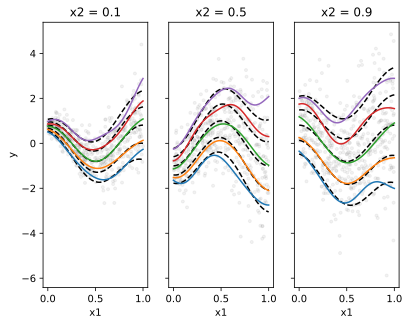

In [ ]:
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, len(x2_values), sharey=True)

for i, x2_val in enumerate(x2_values):
    ax = axes[i]

    mask = x[:, 1] == x2_val
    ax.scatter(x[mask, 0].cpu(), y[mask].cpu(), c="gray", marker=".", alpha=0.1)

    x_line = x_pred[i]
    true_q_lines = mean(x_line).unsqueeze(-1) + std(x_line).unsqueeze(-1) * Normal(
        0, 1
    ).icdf(q)

    ax.plot(x_line[..., 0].cpu(), true_q_lines.cpu(), "--", color="k")

    for j in range(len(q)):
        ax.plot(x_line[..., 0].cpu(), mean_q[j, i, ...].cpu(), color=colors[j])

    ax.set_title(f"x2 = {x2_val:.1f}")
    ax.set_xlabel("x1")
    if i == 0:
        ax.set_ylabel("y")

plt.show()